In [1]:
import jax
from jax import flatten_util 
import jax.numpy as jnp
import jax.random as jr
import diffrax
from diffrax import ControlTerm, MultiTerm, ODETerm
import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, CD1_gradient
jax.config.update("jax_enable_x64", True)

In [2]:
# Example usage

# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([0.5, 0.5])

# Define means
means = jnp.array([
    [1.5, 0.0],   # mean of first Gaussian
    [-0.0, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[.01, 0.0],    # covariance of first Gaussian
        [0.0, .01]],
    [[.01, -0.0],   # covariance of second Gaussian
        [-0.0, .01]],
])

# Generate samples
samples_raw = sample_gaussian_mixture(key, n_samples, weights, means, covs)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def rescale_to_pi_interval(data):
    """
    Center data around zero and rescale to [-π, π] interval if needed
    
    Args:
        data: array of shape (n_samples, N_dimensions)
    
    Returns:
        scaled_data: array of same shape, centered and possibly rescaled to [-π, π]
    """
    # Center the data around zero
    data_mean = jnp.mean(data, axis=0)
    centered = data - 0*data_mean
    
    # Check if rescaling is needed for each dimension
    data_min = jnp.min(centered, axis=0)
    data_max = jnp.max(centered, axis=0)
    data_range = data_max - data_min
    
    # Initialize scaled array with centered data
    scaled = centered.copy()
    
    # Only rescale dimensions that exceed [-π, π] interval
    for dim in range(data.shape[1]):
        if data_max[dim] > jnp.pi or data_min[dim] < -jnp.pi:
            print(f"Rescaling dimension {dim} to fit in [-π, π]")
            scaled = scaled.at[:, dim].set((centered[:, dim] / jnp.max(jnp.abs(centered[:, dim]))) * jnp.pi)
    
    return scaled

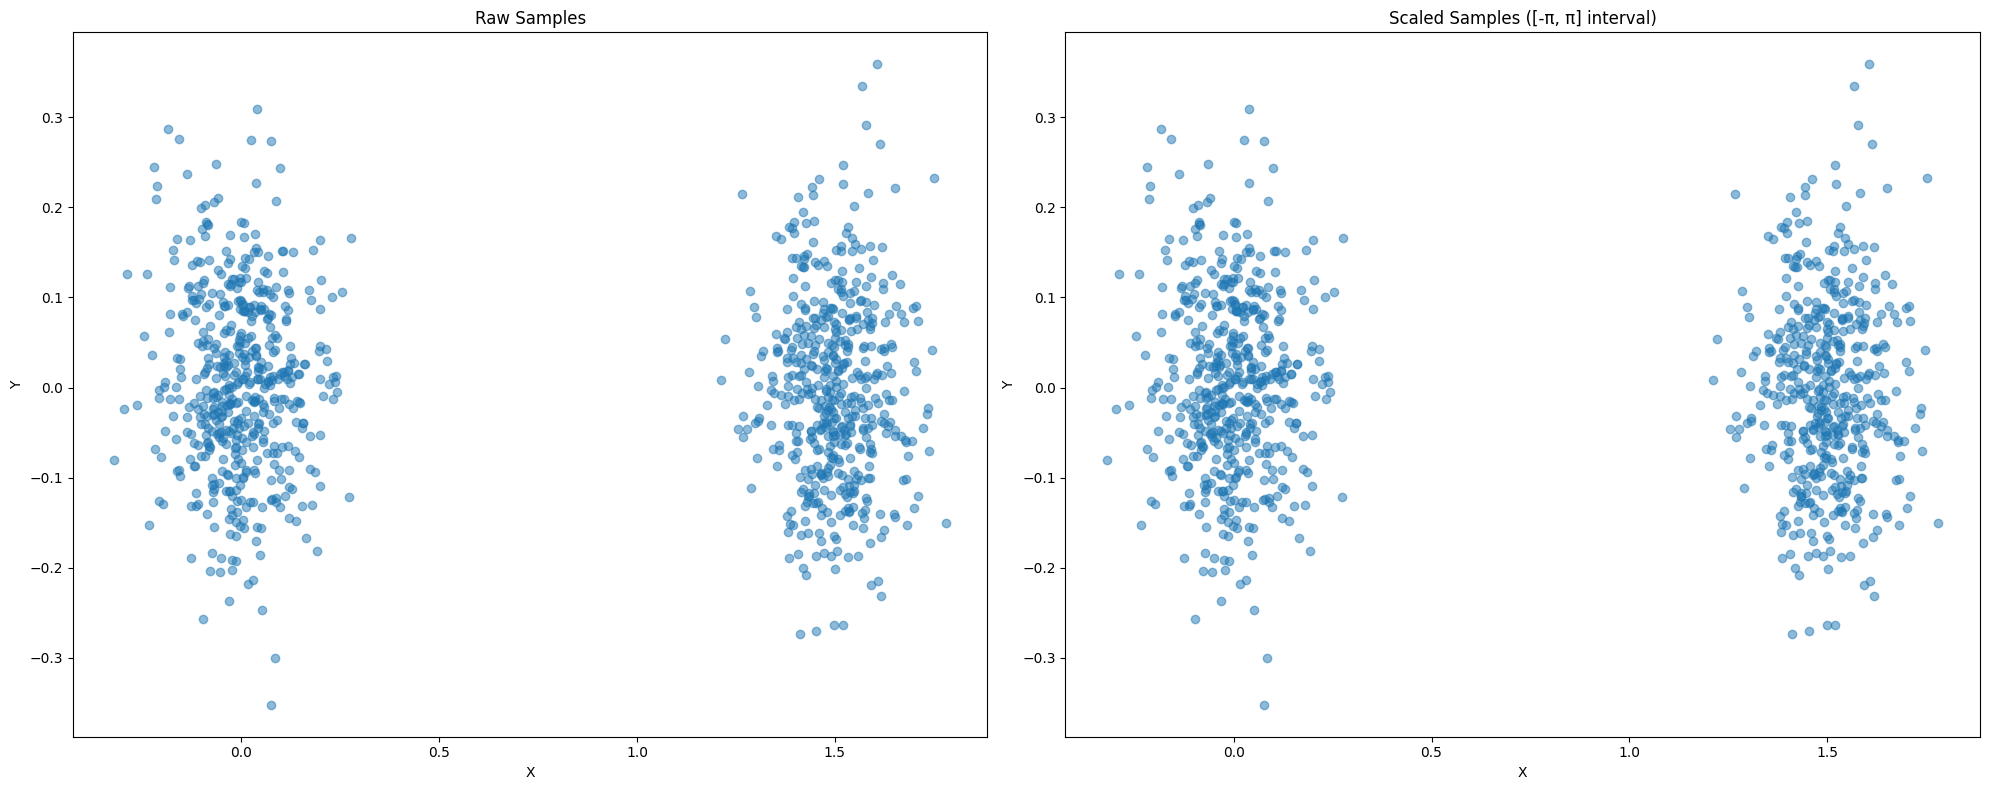

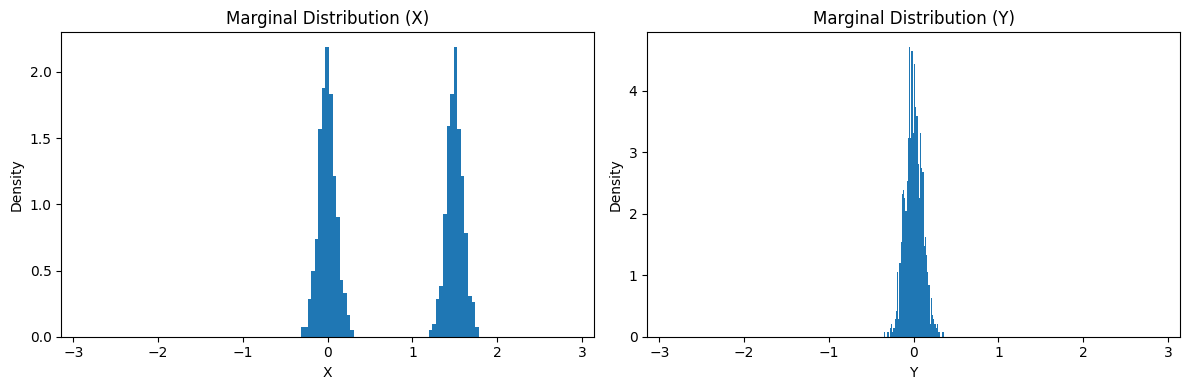

(-3.141592653589793, 3.141592653589793)

In [4]:

samples = rescale_to_pi_interval(samples_raw)

# Plotting
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(20, 8))

# First subplot: Scaled samples
ax1.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
ax1.set_title('Scaled Samples ([-π, π] interval)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Raw samples
ax2.scatter(samples_raw[:, 0], samples_raw[:, 1], alpha=0.5)
ax2.set_title('Raw Samples')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()

# Plot marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(samples[:, 0], bins=50, density=True)
ax1.set_title('Marginal Distribution (X)')
ax1.set_xlabel('X')
ax1.set_ylabel('Density')
ax1.set_xlim(-jnp.pi, jnp.pi)  # Set x-axis limits to [-π, π]

ax2.hist(samples[:, 1], bins=50, density=True)
ax2.set_title('Marginal Distribution (Y)')
ax2.set_xlabel('Y')
ax2.set_ylabel('Density')
ax2.set_xlim(-jnp.pi, jnp.pi)  # Set x-axis limits to [-π, π]

plt.tight_layout()
plt.show()

# For the scatter plot of scaled samples
ax1.set_xlim(-jnp.pi, jnp.pi)  # Set x-axis limits to [-π, π]
ax1.set_ylim(-jnp.pi, jnp.pi)  # Set y-axis limits to [-π, π]

In [5]:
N_osc = 2
# Initialize coupling matrix
W = jnp.zeros((N_osc, N_osc))
# Set symmetric coupling
W = W.at[0,1].set(1.)
W = W.at[1,0].set(1.)  # Make it symmetric
# Initialize biases
h = jnp.zeros(N_osc)
h = h.at[0].set(-10)
args_initial = (W, h)
flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

In [6]:
def XY_energy(x, flattened_args):
    """
    Compute the energy of the XY model
    Args:
        x: array of phases (shape: N_osc)
        W: coupling matrix (shape: N_osc x N_osc)
        h: local biases (shape: N_osc)
    Returns:
        energy: scalar
    """
    W, h = unflatten(flattened_args)
    # Compute coupling energy
    coupling = -jnp.sum(W * jnp.cos(x[:, None] - x[None, :]))
    # Compute bias energy
    bias = -jnp.sum(h * jnp.cos(x))
    return coupling + bias

energy_fn = XY_energy

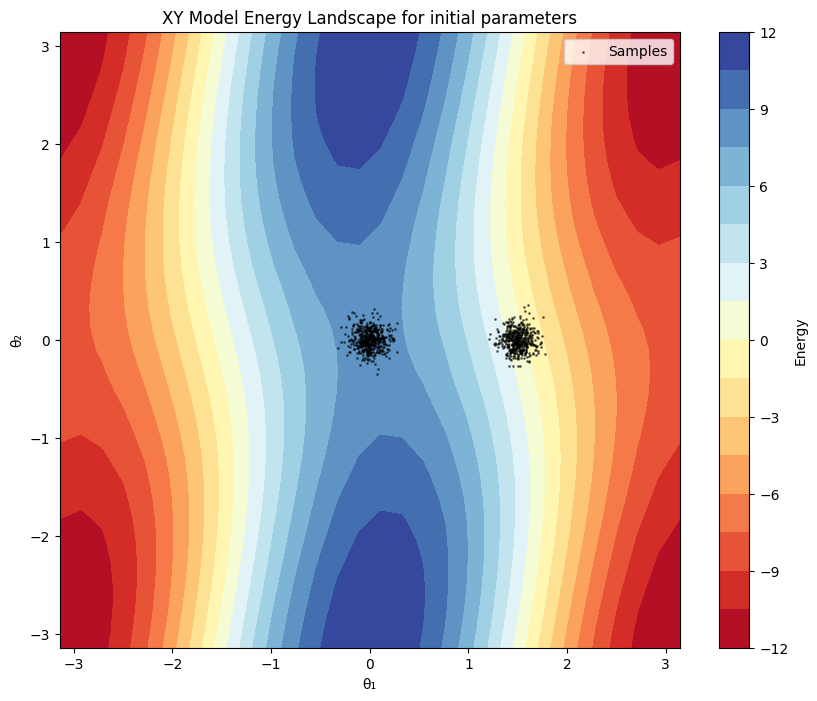

In [7]:
# Create a grid of phase values
n_points = 30
x1 = jnp.linspace(-jnp.pi, jnp.pi, n_points)
x2 = jnp.linspace(-jnp.pi, jnp.pi, n_points)
X1, X2 = jnp.meshgrid(x1, x2)

# Compute energy for each point in the grid
energy = jnp.zeros((n_points, n_points))
for i in range(n_points):
    for j in range(n_points):
        x = jnp.array([X1[i,j], X2[i,j]])
        energy = energy.at[i,j].set(energy_fn(x, flattened_args_initial))

# Create the contour plot
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, energy, levels=20, cmap='RdYlBu')
plt.colorbar(label='Energy')
# Add scatter plot of samples
plt.scatter(samples[:, 0], samples[:, 1], c='black', s=1, alpha=0.5, label='Samples')
plt.xlabel('θ₁')
plt.ylabel('θ₂')
plt.title('XY Model Energy Landscape for initial parameters')
plt.legend()
plt.show()


In [24]:
# Define optimization parameters
learning_rate = 0.001
n_epochs = 200000
batch_size = 128

# Initialize optimizer
optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(flattened_args_initial)

# Training loop
@partial(jax.jit, static_argnums=(3,))
def training_step(params, opt_state, samples, n_samples, key):
    """Single training step using CD-1"""
    # Get gradient of parameters
    dparams = CD1_gradient(energy_fn, samples, params, dt=0.000001, D=1, key=14, num_noise_samples=0)
    
    # Compute log likelihood (negative energy)
    loss = -jnp.mean(jax.vmap(lambda x: energy_fn(x, params))(samples))
    
    # Apply updates
    updates, opt_state = optimizer.update(dparams, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, key, loss

# Training loop
key = jr.PRNGKey(0)
params_history = []
loss_history = []

params = flattened_args_initial  # Use the flattened initial parameters

for epoch in range(n_epochs):
    key, subkey = jr.split(key)
    params, opt_state, key, loss = training_step(params, opt_state, samples, batch_size, subkey)
    
    # Store parameters and loss
    params_history.append(params)
    loss_history.append(loss)
    
    if epoch % 10 == 0:
        # Unflatten only for printing
        W, h = unflatten(params)
        print(f"Epoch {epoch}")
        print(f"W:\n{W}")
        print(f"h:\n{h}")
        print(f"Loss: {loss:.4f}")
        print("---")



(1000, 6)
Epoch 0
W:
[[-2.08166817e-12  9.99006894e-01]
 [ 9.99006894e-01 -2.08166817e-12]]
h:
[-1.00009949e+01  4.19340194e-04]
Loss: -4.3781
---
Epoch 10
W:
[[-2.28983498e-11  9.89072191e-01]
 [ 9.89072191e-01 -2.28983498e-11]]
h:
[-1.00109452e+01  4.60683614e-03]
Loss: -4.3901
---
Epoch 20
W:
[[-4.37150315e-11  9.79121835e-01]
 [ 9.79121835e-01 -4.37150315e-11]]
h:
[-1.00209025e+01  8.78029919e-03]
Loss: -4.4022
---
Epoch 30
W:
[[-6.45317132e-11  9.69145465e-01]
 [ 9.69145465e-01 -6.45317132e-11]]
h:
[-10.0308715    0.01293584]
Loss: -4.4143
---
Epoch 40
W:
[[-8.53483948e-11  9.59136379e-01]
 [ 9.59136379e-01 -8.53483948e-11]]
h:
[-10.04085523   0.0170708 ]
Loss: -4.4265
---
Epoch 50
W:
[[-1.06165077e-10  9.49090914e-01]
 [ 9.49090914e-01 -1.06165077e-10]]
h:
[-10.05085544   0.02118352]
Loss: -4.4387
---
Epoch 60
W:
[[-1.26981758e-10  9.39007371e-01]
 [ 9.39007371e-01 -1.26981758e-10]]
h:
[-10.06087297   0.02527305]
Loss: -4.4510
---
Epoch 70
W:
[[-1.47798440e-10  9.28885131e-01]
 [

In [25]:
# Convert histories to arrays for plotting
slicing = 100
params_history = jnp.array(params_history[::slicing])
W_history = jnp.zeros((len(params_history), N_osc, N_osc))
h_history = jnp.zeros((len(params_history), N_osc))
for i in range(len(params_history)):
    params_history_i = unflatten(params_history[i])
    W_history=W_history.at[i,:,:].set(params_history_i[0])
    h_history=h_history.at[i,:].set(params_history_i[1])
loss_history = jnp.array(loss_history[::slicing])


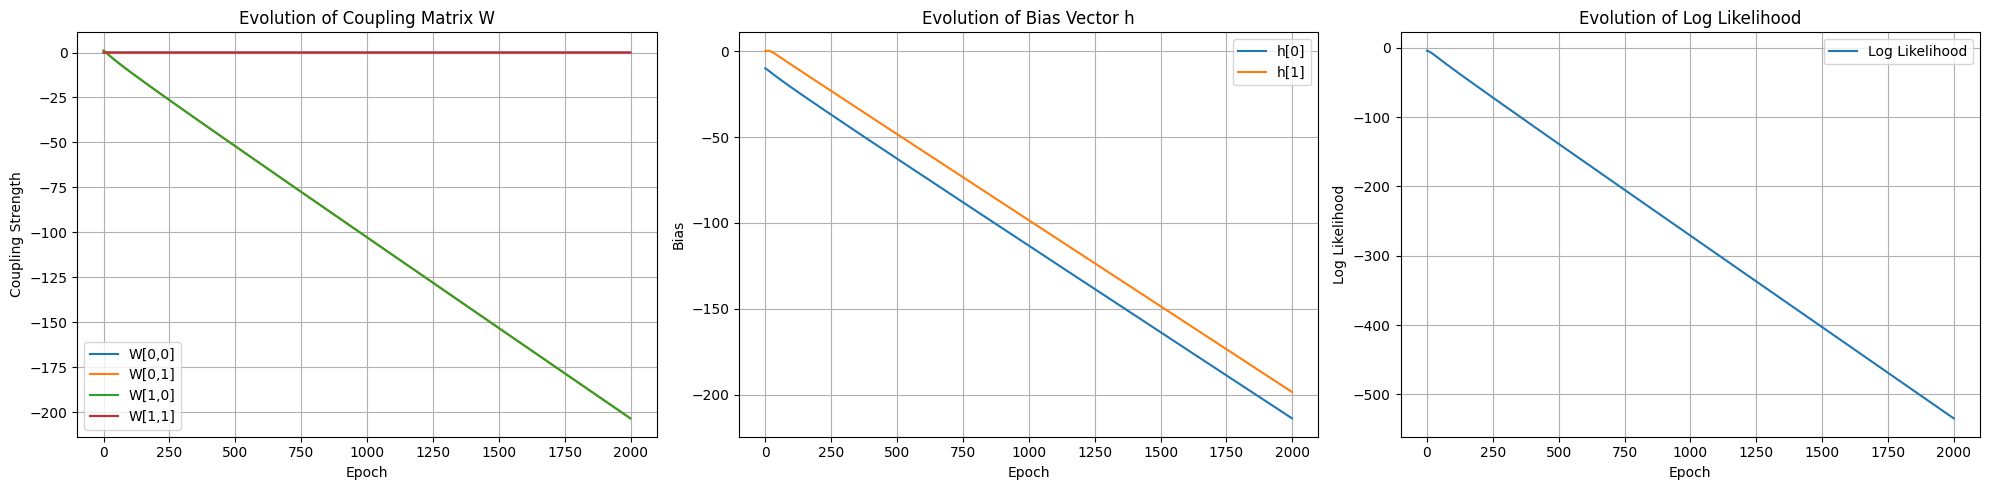

In [26]:
# Plot parameter evolution and loss
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# Plot W evolution
for i in range(N_osc):
    for j in range(N_osc):
        ax1.plot(W_history[:, i, j], 
                label=f'W[{i},{j}]')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Coupling Strength')
ax1.set_title('Evolution of Coupling Matrix W')
ax1.legend()
ax1.grid(True)

# Plot h evolution
for i in range(N_osc):
    ax2.plot(h_history[:, i], label=f'h[{i}]')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Bias')
ax2.set_title('Evolution of Bias Vector h')
ax2.legend()
ax2.grid(True)

# Plot loss evolution
ax3.plot(loss_history, label='Log Likelihood')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Log Likelihood')
ax3.set_title('Evolution of Log Likelihood')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

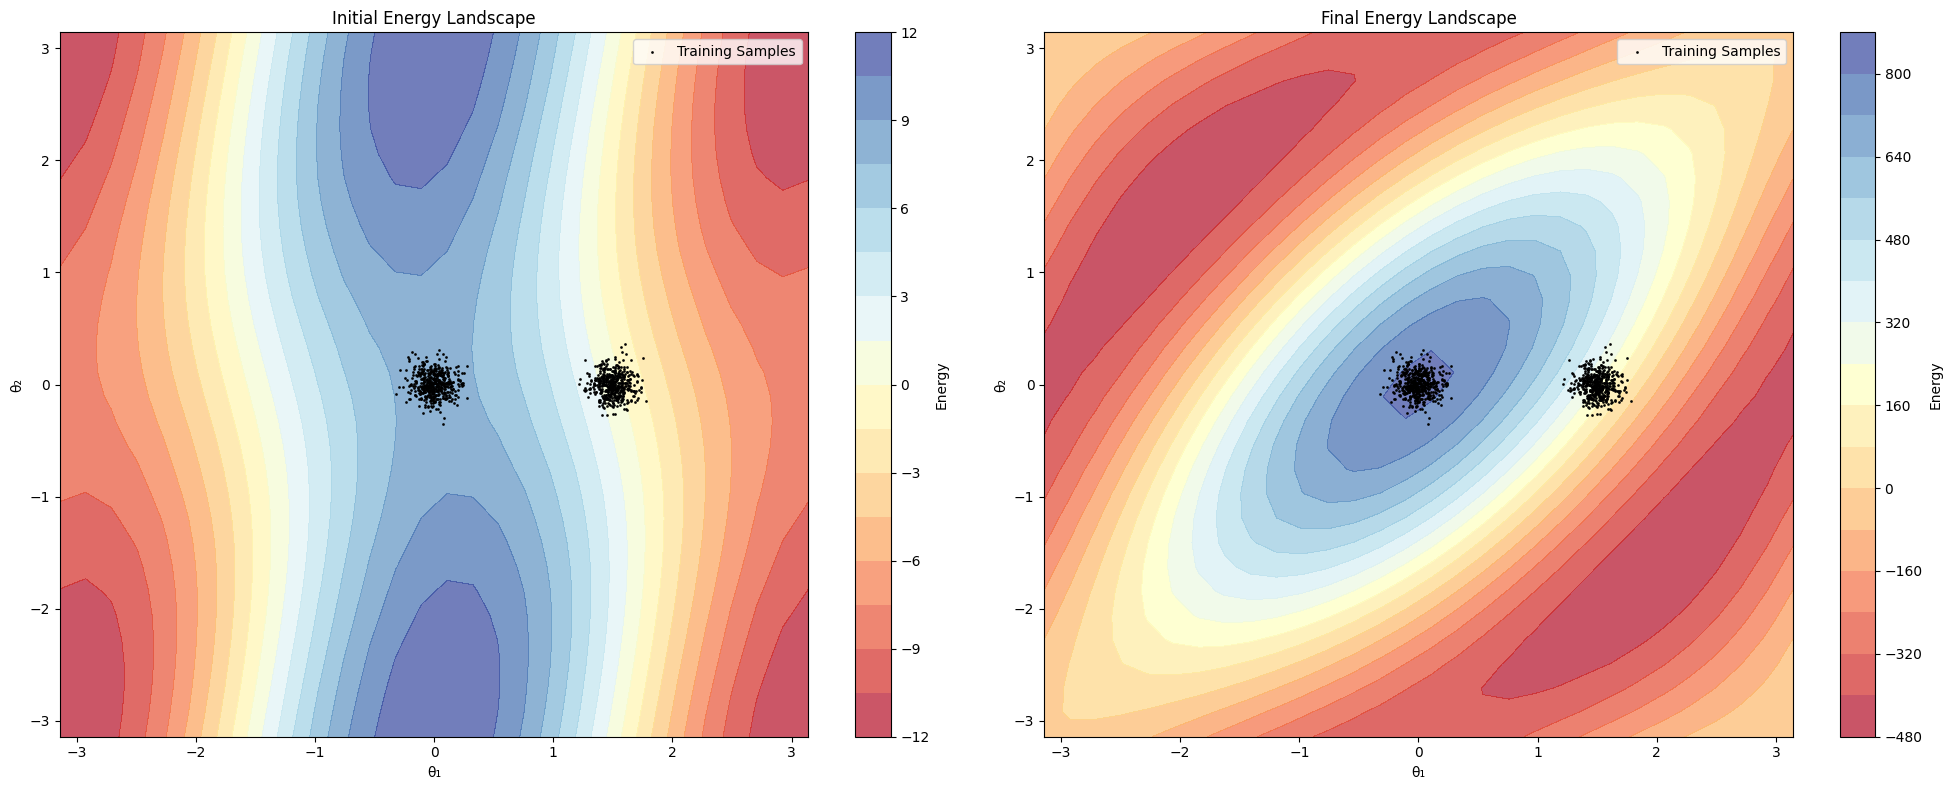

In [27]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot initial energy landscape
energy_initial = jnp.zeros((n_points, n_points))
energy_final = jnp.zeros((n_points, n_points))
for i in range(n_points):
    for j in range(n_points):
        x = jnp.array([X1[i,j], X2[i,j]])
        energy_initial = energy_initial.at[i,j].set(energy_fn(x, flattened_args_initial))
        energy_final = energy_final.at[i,j].set(energy_fn(x, params))

contour1 = ax1.contourf(X1, X2, energy_initial, levels=20, cmap='RdYlBu', alpha=0.7)
plt.colorbar(contour1, ax=ax1, label='Energy')
ax1.scatter(samples[:, 0], samples[:, 1], c='black', s=1, alpha=0.9, label='Training Samples')
ax1.set_xlabel('θ₁')
ax1.set_ylabel('θ₂')
ax1.set_title('Initial Energy Landscape')
ax1.legend()


contour2 = ax2.contourf(X1, X2, energy_final, levels=20, cmap='RdYlBu', alpha=0.7)
plt.colorbar(contour2, ax=ax2, label='Energy')
ax2.scatter(samples[:, 0], samples[:, 1], c='black', s=1, alpha=0.9, label='Training Samples')
ax2.set_xlabel('θ₁')
ax2.set_ylabel('θ₂')
ax2.set_title('Final Energy Landscape')
ax2.legend()

plt.tight_layout()
plt.show()

In [3]:
def drift_x_fn(t, state, args):
    """
    Drift function for the XY model with effective temperature
    Args:
        t: time
        state: array of phases (shape: N_osc)
        args: tuple containing (W, h)
    Returns:
        Array of phase velocities
    """
    W, h = args
    # Compute force from energy gradient
    dE_dtheta = jax.grad(XY_energy, argnums=0)(state, W, h)
    
    # Damping term
    gamma = 1.0  # Damping coefficient, adjust as needed
    
    dtheta_dt = -gamma * dE_dtheta
    
    return dtheta_dt

def diffusion_x_fn(t, state, args):
    """
    Diffusion function for the XY model with effective temperature
    Args:
        t: time
        state: array of phases (shape: N_osc)
        args: additional arguments
    Returns:
        Noise matrix (shape: N_osc x 1)
    """
    T_eff = 1.0  # Effective temperature, adjust as needed
    gamma = 1.0  # Same damping coefficient as in drift
    
    noise_strength = jnp.sqrt(2 * gamma * T_eff)
    noise_matrix = jnp.eye(N_osc)
    return noise_strength * noise_matrix



In [ ]:
# Calculate characteristic time scales
gamma = 1.0
T_eff = 1.0
J = jnp.max(jnp.abs(W))  # Coupling strength

tau_relax = 1/gamma
tau_diffusion = gamma/(2*T_eff)

print(f"Relaxation time scale: {tau_relax:.2f}")
print(f"Diffusion time scale: {tau_diffusion:.2f}")

# Set simulation time accordingly
t0 = 0.0
t1 = 100 * max(tau_relax, tau_diffusion)  # Simulate for 10x the longest time scale
dt0 = min(tau_relax, tau_diffusion) / 10  # Initial time step should be smaller than fastest time scale

print(f"\nSuggested simulation parameters:")
print(f"Total time: {t1:.2f}")
print(f"Initial dt: {dt0:.2f}")

ts = jnp.linspace(t0, t1, 10000)
dt = ts[1] - ts[0]

y0_x = jnp.array([jnp.pi,jnp.pi])

In [ ]:
# Update shape to match number of oscillators
w_shape = (N_osc,)  # state is just phases for each oscillator
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
saveat = diffrax.SaveAt(ts=ts)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_x,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=1000000000,
    stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping
)
sde_samples_x = solution_x.ys

In [7]:
# # Calculate number of timesteps corresponding to one relaxation time
# relax_steps = int(1/(gamma * dt))

# # Thin the samples by taking every relax_steps point
# sde_samples_x = solution_x.ys[::relax_steps]
# ts = ts[::relax_steps]

In [ ]:
# Create figure with a grid of subplots
fig = plt.figure(figsize=(16, 12))
gs = plt.GridSpec(2, 2, height_ratios=[2, 1])

# Top left: Phase trajectories
ax1 = fig.add_subplot(gs[0, 0])
# Mod 2π for time trajectories
ax1.plot(ts, jnp.mod(sde_samples_x[:, 0], 2*jnp.pi), label='θ₁(t)')
ax1.plot(ts, jnp.mod(sde_samples_x[:, 1], 2*jnp.pi), label='θ₂(t)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Phase (rad)')
ax1.set_title('SDE Simulation: Phase vs Time')
ax1.grid(True)
ax1.legend()

# Top right: Phase space with Energy contour
ax2 = fig.add_subplot(gs[0, 1])
contour = ax2.contourf(X1, X2, energy, levels=20, cmap='RdYlBu')
plt.colorbar(contour, ax=ax2, label='Energy')

# Mod 2π for phase space trajectory
wrapped_x = jnp.mod(sde_samples_x, 2*jnp.pi)
ax2.scatter(wrapped_x[:, 0], wrapped_x[:, 1], c='g', s=1, alpha=0.9999, label='Trajectory')
ax2.plot(wrapped_x[0, 0], wrapped_x[0, 1], 'go', label='Start', markersize=10)


ax2.set_xlabel('θ₁')
ax2.set_ylabel('θ₂')
ax2.set_title('Phase Space (Torus)')
ax2.legend()

# Bottom left: θ₁ histogram (mod 2π)
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(wrapped_x[:, 0], bins=50, density=True, alpha=0.7, label='θ₁ distribution')
ax3.set_xlabel('θ₁')
ax3.set_ylabel('Probability Density')
ax3.grid(True)
ax3.legend()

# Bottom right: θ₂ histogram (mod 2π)
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(wrapped_x[:, 1], bins=50, density=True, alpha=0.7, label='θ₂ distribution')
ax4.set_xlabel('θ₂')
ax4.set_ylabel('Probability Density')
ax4.grid(True)
ax4.legend()

plt.tight_layout()
# Add title with parameters
title = f'T_eff={T_eff}, γ={gamma}'
plt.suptitle(title, y=1.02)

plt.show()